<a href="https://colab.research.google.com/github/gagan3754/-Porter-Neural-Networks-Regression/blob/main/Porter_Neural_Networks_Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Porter is India's Largest Marketplace for Intra-City Logistics. Leader in the country's $40 billion intra-city logistics market, Porter strives to improve the lives of 1,50,000+ driver-partners by providing them with consistent earning & independence. Currently, the company has serviced 5+ million customers

Porter works with a wide range of restaurants for delivering their items directly to the people.

Porter has a number of delivery partners available for delivering the food, from various restaurants and wants to get an estimated delivery time that it can provide the customers on the basis of what they are ordering, from where and also the delivery partners.

This dataset has the required data to train a regression model that will do the delivery time estimation, based on all those features

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!gdown https://drive.google.com/uc?id=1NEekLFZpi0nJvkbaHnoilS95chk3dd0g -O porter.csv

Downloading...
From: https://drive.google.com/uc?id=1NEekLFZpi0nJvkbaHnoilS95chk3dd0g
To: /content/porter.csv
100% 15.7M/15.7M [00:00<00:00, 41.6MB/s]


In [ ]:
df=pd.read_csv('porter.csv')

In [ ]:
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0


shape of data

In [ ]:
df.shape

(175777, 14)

In [ ]:
print("No of Samples  :",df.shape[0])
print("No of Features :",df.shape[1])

No of Samples  : 175777
No of Features : 14


In [ ]:
# Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   created_at                                    175777 non-null  object 
 2   actual_delivery_time                          175777 non-null  object 
 3   store_primary_category                        175777 non-null  int64  
 4   order_protocol                                175777 non-null  float64
 5   total_items                                   175777 non-null  int64  
 6   subtotal                                      175777 non-null  int64  
 7   num_distinct_items                            175777 non-null  int64  
 8   min_item_price                                175777 non-null  int64  
 9   max_item_price                                17

Describe the data

In [ ]:
#describe data

df.describe()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
count,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000
mean,2.743726,35.887949,2.911752,3.204976,2697.111147,2.675060,684.965433,1160.158616,44.918664,41.861381,58.230115,546.077240
std,1.330963,20.728254,1.513128,2.674055,1828.554893,1.625681,519.882924,560.828571,34.544724,32.168505,52.731043,218.717798
min,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000,0.000000
25%,2.000000,18.000000,1.000000,2.000000,1412.000000,1.000000,299.000000,799.000000,17.000000,15.000000,17.000000,384.000000
50%,2.000000,38.000000,3.000000,3.000000,2224.000000,2.000000,595.000000,1095.000000,37.000000,35.000000,41.000000,544.000000
75%,4.000000,55.000000,4.000000,4.000000,3410.000000,3.000000,942.000000,1395.000000,66.000000,63.000000,85.000000,703.000000
max,6.000000,72.000000,7.000000,411.000000,26800.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000,2088.000000


In [ ]:
#Unique value of each feature

In [ ]:
for i in df.columns:
  print(i,"Unique values :" ,df[i].nunique())
  print("-"*50)
  print()

market_id Unique values : 6
--------------------------------------------------

created_at Unique values : 162649
--------------------------------------------------

actual_delivery_time Unique values : 160344
--------------------------------------------------

store_primary_category Unique values : 73
--------------------------------------------------

order_protocol Unique values : 7
--------------------------------------------------

total_items Unique values : 54
--------------------------------------------------

subtotal Unique values : 8182
--------------------------------------------------

num_distinct_items Unique values : 20
--------------------------------------------------

min_item_price Unique values : 2251
--------------------------------------------------

max_item_price Unique values : 2585
--------------------------------------------------

total_onshift_dashers Unique values : 172
--------------------------------------------------

total_busy_dashers Unique values :

Checking any duplicates values

In [ ]:
df.duplicated().sum()

np.int64(0)

Ther are no duplicates

In [ ]:
#converting created_at and actual_delivery time to datetime

df['created_at']=pd.to_datetime(df['created_at'])
df['actual_delivery_time']=pd.to_datetime(df['actual_delivery_time'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   market_id                                     175777 non-null  float64       
 1   created_at                                    175777 non-null  datetime64[ns]
 2   actual_delivery_time                          175777 non-null  datetime64[ns]
 3   store_primary_category                        175777 non-null  int64         
 4   order_protocol                                175777 non-null  float64       
 5   total_items                                   175777 non-null  int64         
 6   subtotal                                      175777 non-null  int64         
 7   num_distinct_items                            175777 non-null  int64         
 8   min_item_price                                175777 n

Feature engineering: Creating the target column time taken in each delivery from order timestamp (created_at) and delivery timestamp (actual_delivery_time)

In [ ]:
df1=df.copy()

In [ ]:
df1['delivery_time']=df1['actual_delivery_time']-df1['created_at']
df1.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,delivery_time
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,0 days 00:47:00
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,0 days 00:44:00
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,0 days 00:55:00
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,0 days 00:59:00
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,0 days 00:46:00


Getting hour of day from the order time and also the day of the week

Get delivery time in minutes

In [ ]:
df1['created_hour']=df1['created_at'].dt.hour
df1['created_week']=df1['created_at'].dt.dayofweek

In [ ]:
df1.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,delivery_time,created_hour,created_week
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,0 days 00:47:00,22,4
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,0 days 00:44:00,21,1
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,0 days 00:55:00,0,0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,0 days 00:59:00,3,3
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,0 days 00:46:00,2,1


Get delivery time in minutes


In [ ]:
df1['delivery_time_minutes']=df1['delivery_time'].dt.total_seconds()/60
df1.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,delivery_time,created_hour,created_week,delivery_time_minutes
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,0 days 00:47:00,22,4,47.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,0 days 00:44:00,21,1,44.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,0 days 00:55:00,0,0,55.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,0 days 00:59:00,3,3,59.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,0 days 00:46:00,2,1,46.0


In [ ]:
df1.describe()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,delivery_time,created_hour,created_week,delivery_time_minutes
count,175777.000000,175777,175777,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777,175777.000000,175777.000000,175777.000000
mean,2.743726,2015-02-04 19:57:50.009631744,2015-02-04 20:44:02.190406144,35.887949,2.911752,3.204976,2697.111147,2.675060,684.965433,1160.158616,44.918664,41.861381,58.230115,546.077240,0 days 00:46:12.180774504,8.473441,3.222293,46.203013
min,1.000000,2015-01-21 15:22:03,2015-01-21 16:07:03,0.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000,0.000000,0 days 00:32:00,0.000000,0.000000,32.000000
25%,2.000000,2015-01-29 01:31:19,2015-01-29 02:16:30,18.000000,1.000000,2.000000,1412.000000,1.000000,299.000000,799.000000,17.000000,15.000000,17.000000,384.000000,0 days 00:39:00,2.000000,1.000000,39.000000
50%,2.000000,2015-02-05 02:41:26,2015-02-05 03:34:33,38.000000,3.000000,3.000000,2224.000000,2.000000,595.000000,1095.000000,37.000000,35.000000,41.000000,544.000000,0 days 00:45:00,3.000000,3.000000,45.000000
75%,4.000000,2015-02-12 01:04:32,2015-02-12 01:48:24,55.000000,4.000000,4.000000,3410.000000,3.000000,942.000000,1395.000000,66.000000,63.000000,85.000000,703.000000,0 days 00:52:00,19.000000,5.000000,52.000000
max,6.000000,2015-02-18 06:00:44,2015-02-18 06:51:10,72.000000,7.000000,411.000000,26800.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000,2088.000000,0 days 01:50:00,23.000000,6.000000,110.000000
std,1.330963,NaN,NaN,20.728254,1.513128,2.674055,1828.554893,1.625681,519.882924,560.828571,34.544724,32.168505,52.731043,218.717798,0 days 00:09:19.645460135,8.676809,2.043874,9.327424


Drop columns created_at , actual_delivery_time and delivery_time

In [ ]:
df1.drop(columns=['created_at','actual_delivery_time','delivery_time'],inplace=True)
df1.head()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,created_hour,created_week,delivery_time_minutes
0,1.0,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,22,4,47.0
1,2.0,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,21,1,44.0
2,2.0,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,0,0,55.0
3,1.0,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,3,3,59.0
4,1.0,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,2,1,46.0


Handling null values

In [ ]:
df1.isnull().sum()/len(df1)*100

,0
market_id,0.0
store_primary_category,0.0
order_protocol,0.0
total_items,0.0
subtotal,0.0
num_distinct_items,0.0
min_item_price,0.0
max_item_price,0.0
total_onshift_dashers,0.0
total_busy_dashers,0.0


There are no Null values to handle in the data

Check if there are any categorical variable to encode

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 15 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   store_primary_category                        175777 non-null  int64  
 2   order_protocol                                175777 non-null  float64
 3   total_items                                   175777 non-null  int64  
 4   subtotal                                      175777 non-null  int64  
 5   num_distinct_items                            175777 non-null  int64  
 6   min_item_price                                175777 non-null  int64  
 7   max_item_price                                175777 non-null  int64  
 8   total_onshift_dashers                         175777 non-null  float64
 9   total_busy_dashers                            17

There are no categorical variable to encode

In [ ]:
df1.head()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,created_hour,created_week,delivery_time_minutes
0,1.0,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,22,4,47.0
1,2.0,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,21,1,44.0
2,2.0,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,0,0,55.0
3,1.0,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,3,3,59.0
4,1.0,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,2,1,46.0


Data visualization and cleaning

Visualize various columns for better understanding Countplots, scatterplots

Let's visualize the distribution using Histplot and range using boxplot

In [ ]:
cols=['subtotal','min_item_price','max_item_price','total_onshift_dashers','total_busy_dashers','total_outstanding_orders','estimated_store_to_consumer_driving_duration','delivery_time_minutes']

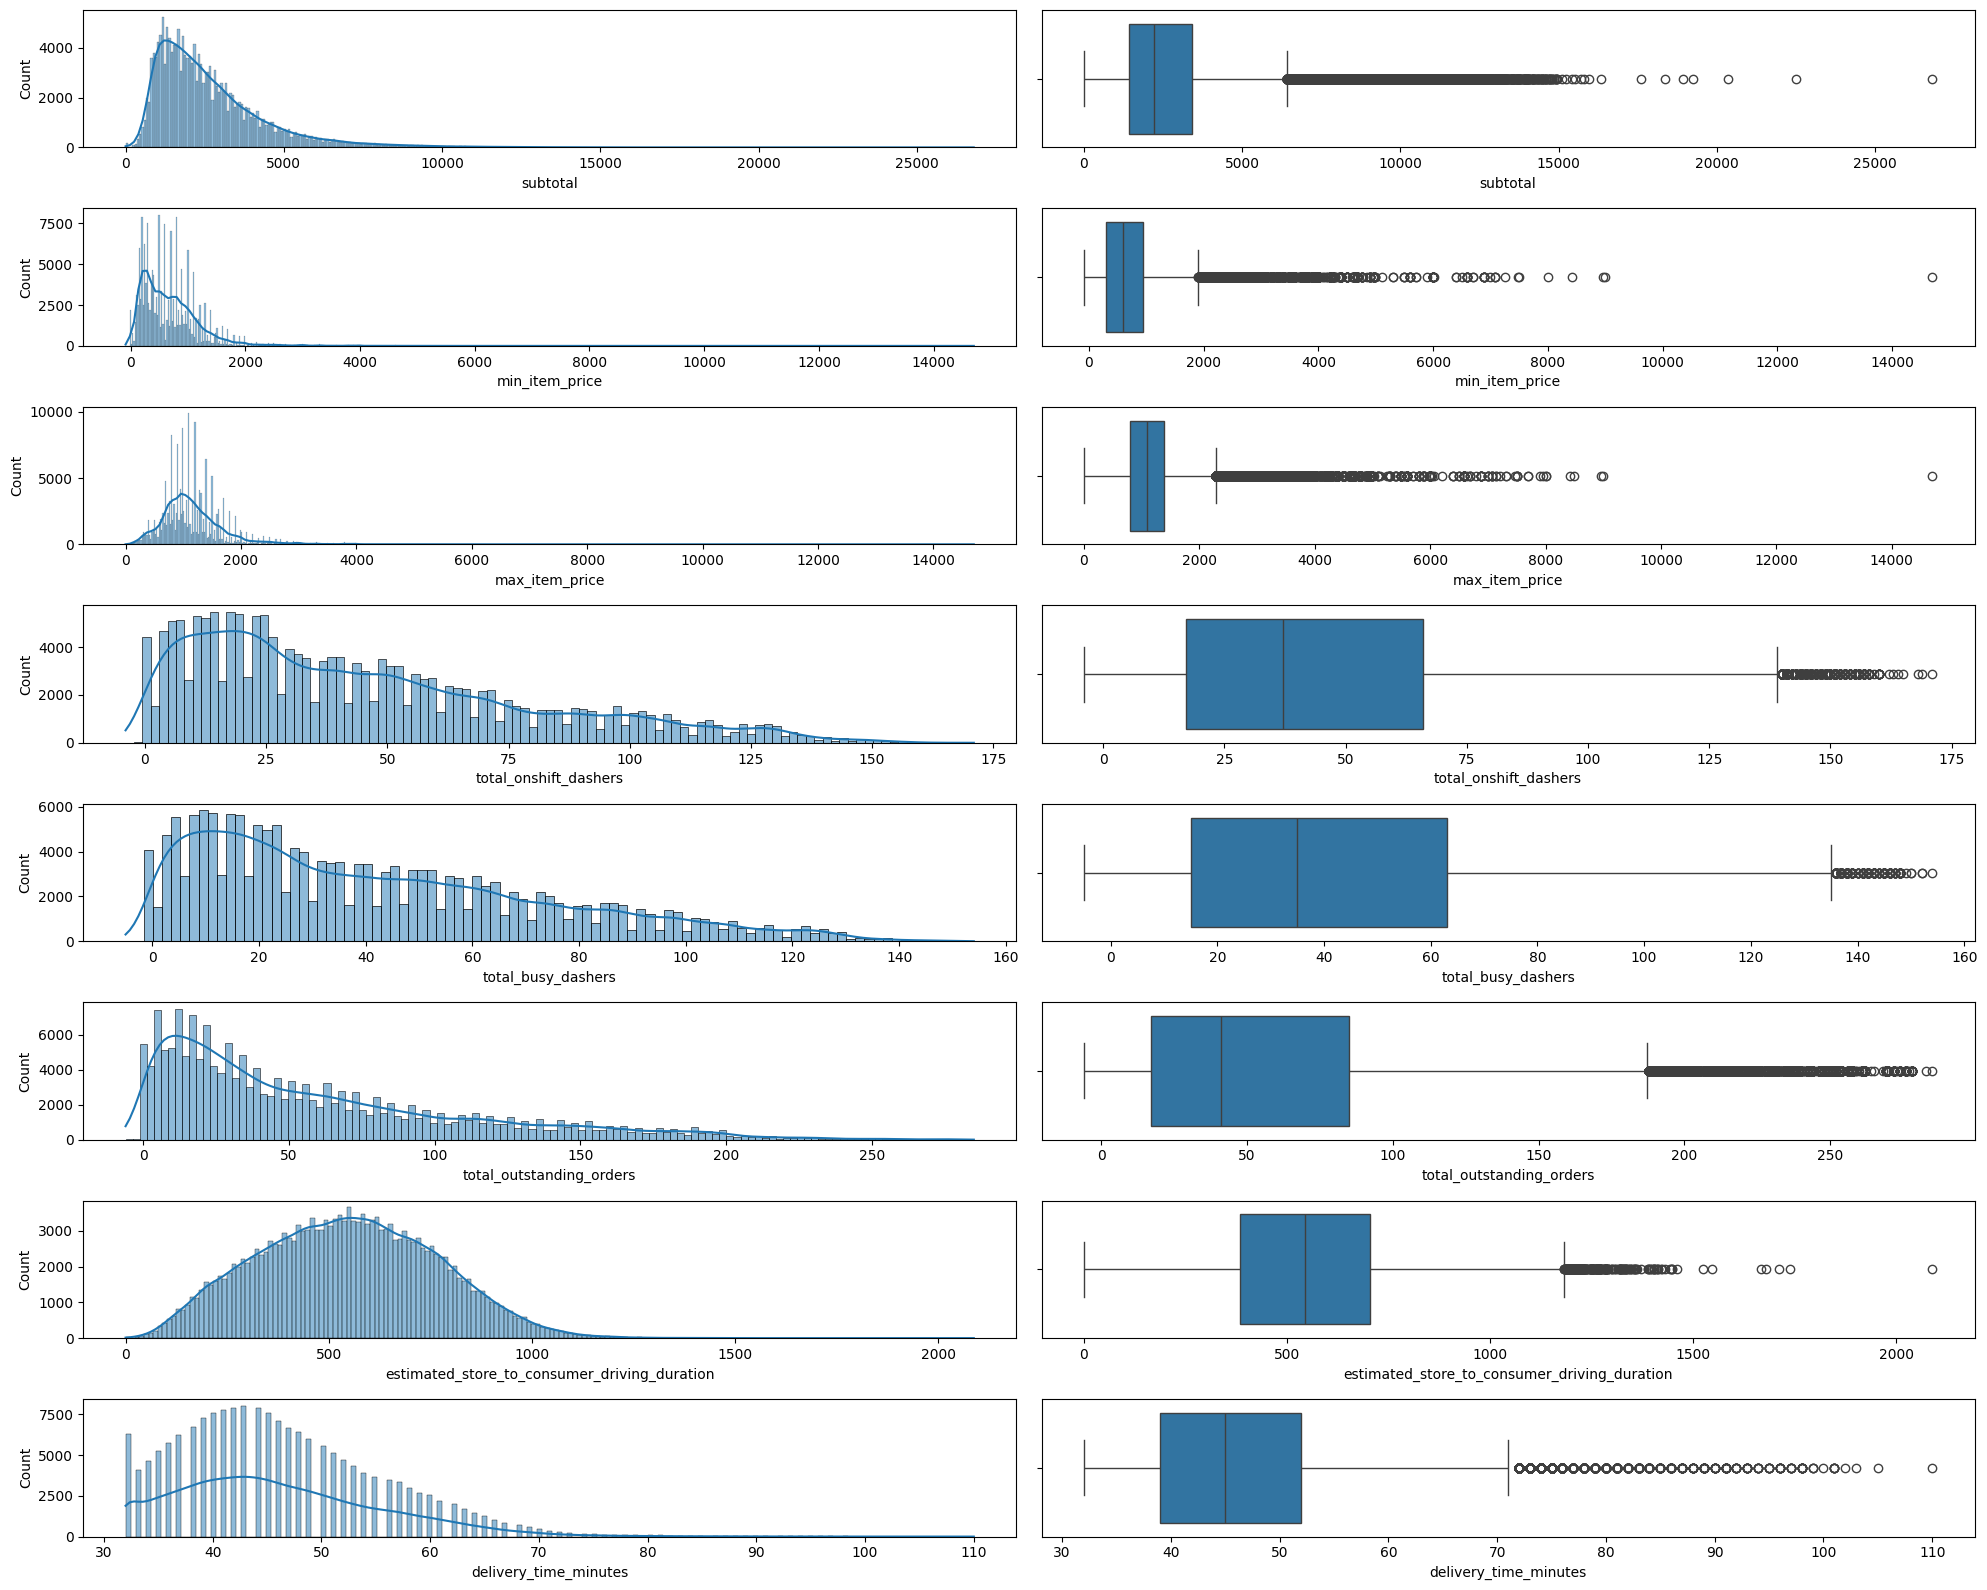

In [ ]:
fig,axes=plt.subplots(len(cols),2,figsize=(20,16))

for i,col in enumerate(cols):
  sns.histplot(df1[col],ax=axes[i,0],kde=True)

  sns.boxplot(x=df1[col],ax=axes[i,1])
plt.tight_layout()
plt.show()

Insights :

 sub total has a range between 0 and 5000 and is right skewed

 min_price and max_price has range from 0 to 2000

 estimated_store_to_consumer_driving_duration is normally distributed

All the features sub_total , min_price , max_price , delivery_time_minutes has outliers


Countplot

In [ ]:
df1.head()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,created_hour,created_week,delivery_time_minutes
0,1.0,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,22,4,47.0
1,2.0,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,21,1,44.0
2,2.0,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,0,0,55.0
3,1.0,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,3,3,59.0
4,1.0,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,2,1,46.0


In [ ]:
cols1=list(set(df1.columns).difference(set(cols)))
cols1

['total_items',
 'market_id',
 'created_week',
 'store_primary_category',
 'order_protocol',
 'num_distinct_items',
 'created_hour']

In [ ]:
cols1=['created_week',
 'created_hour',
 'order_protocol',
 'market_id',
 'num_distinct_items']

In [ ]:
import math

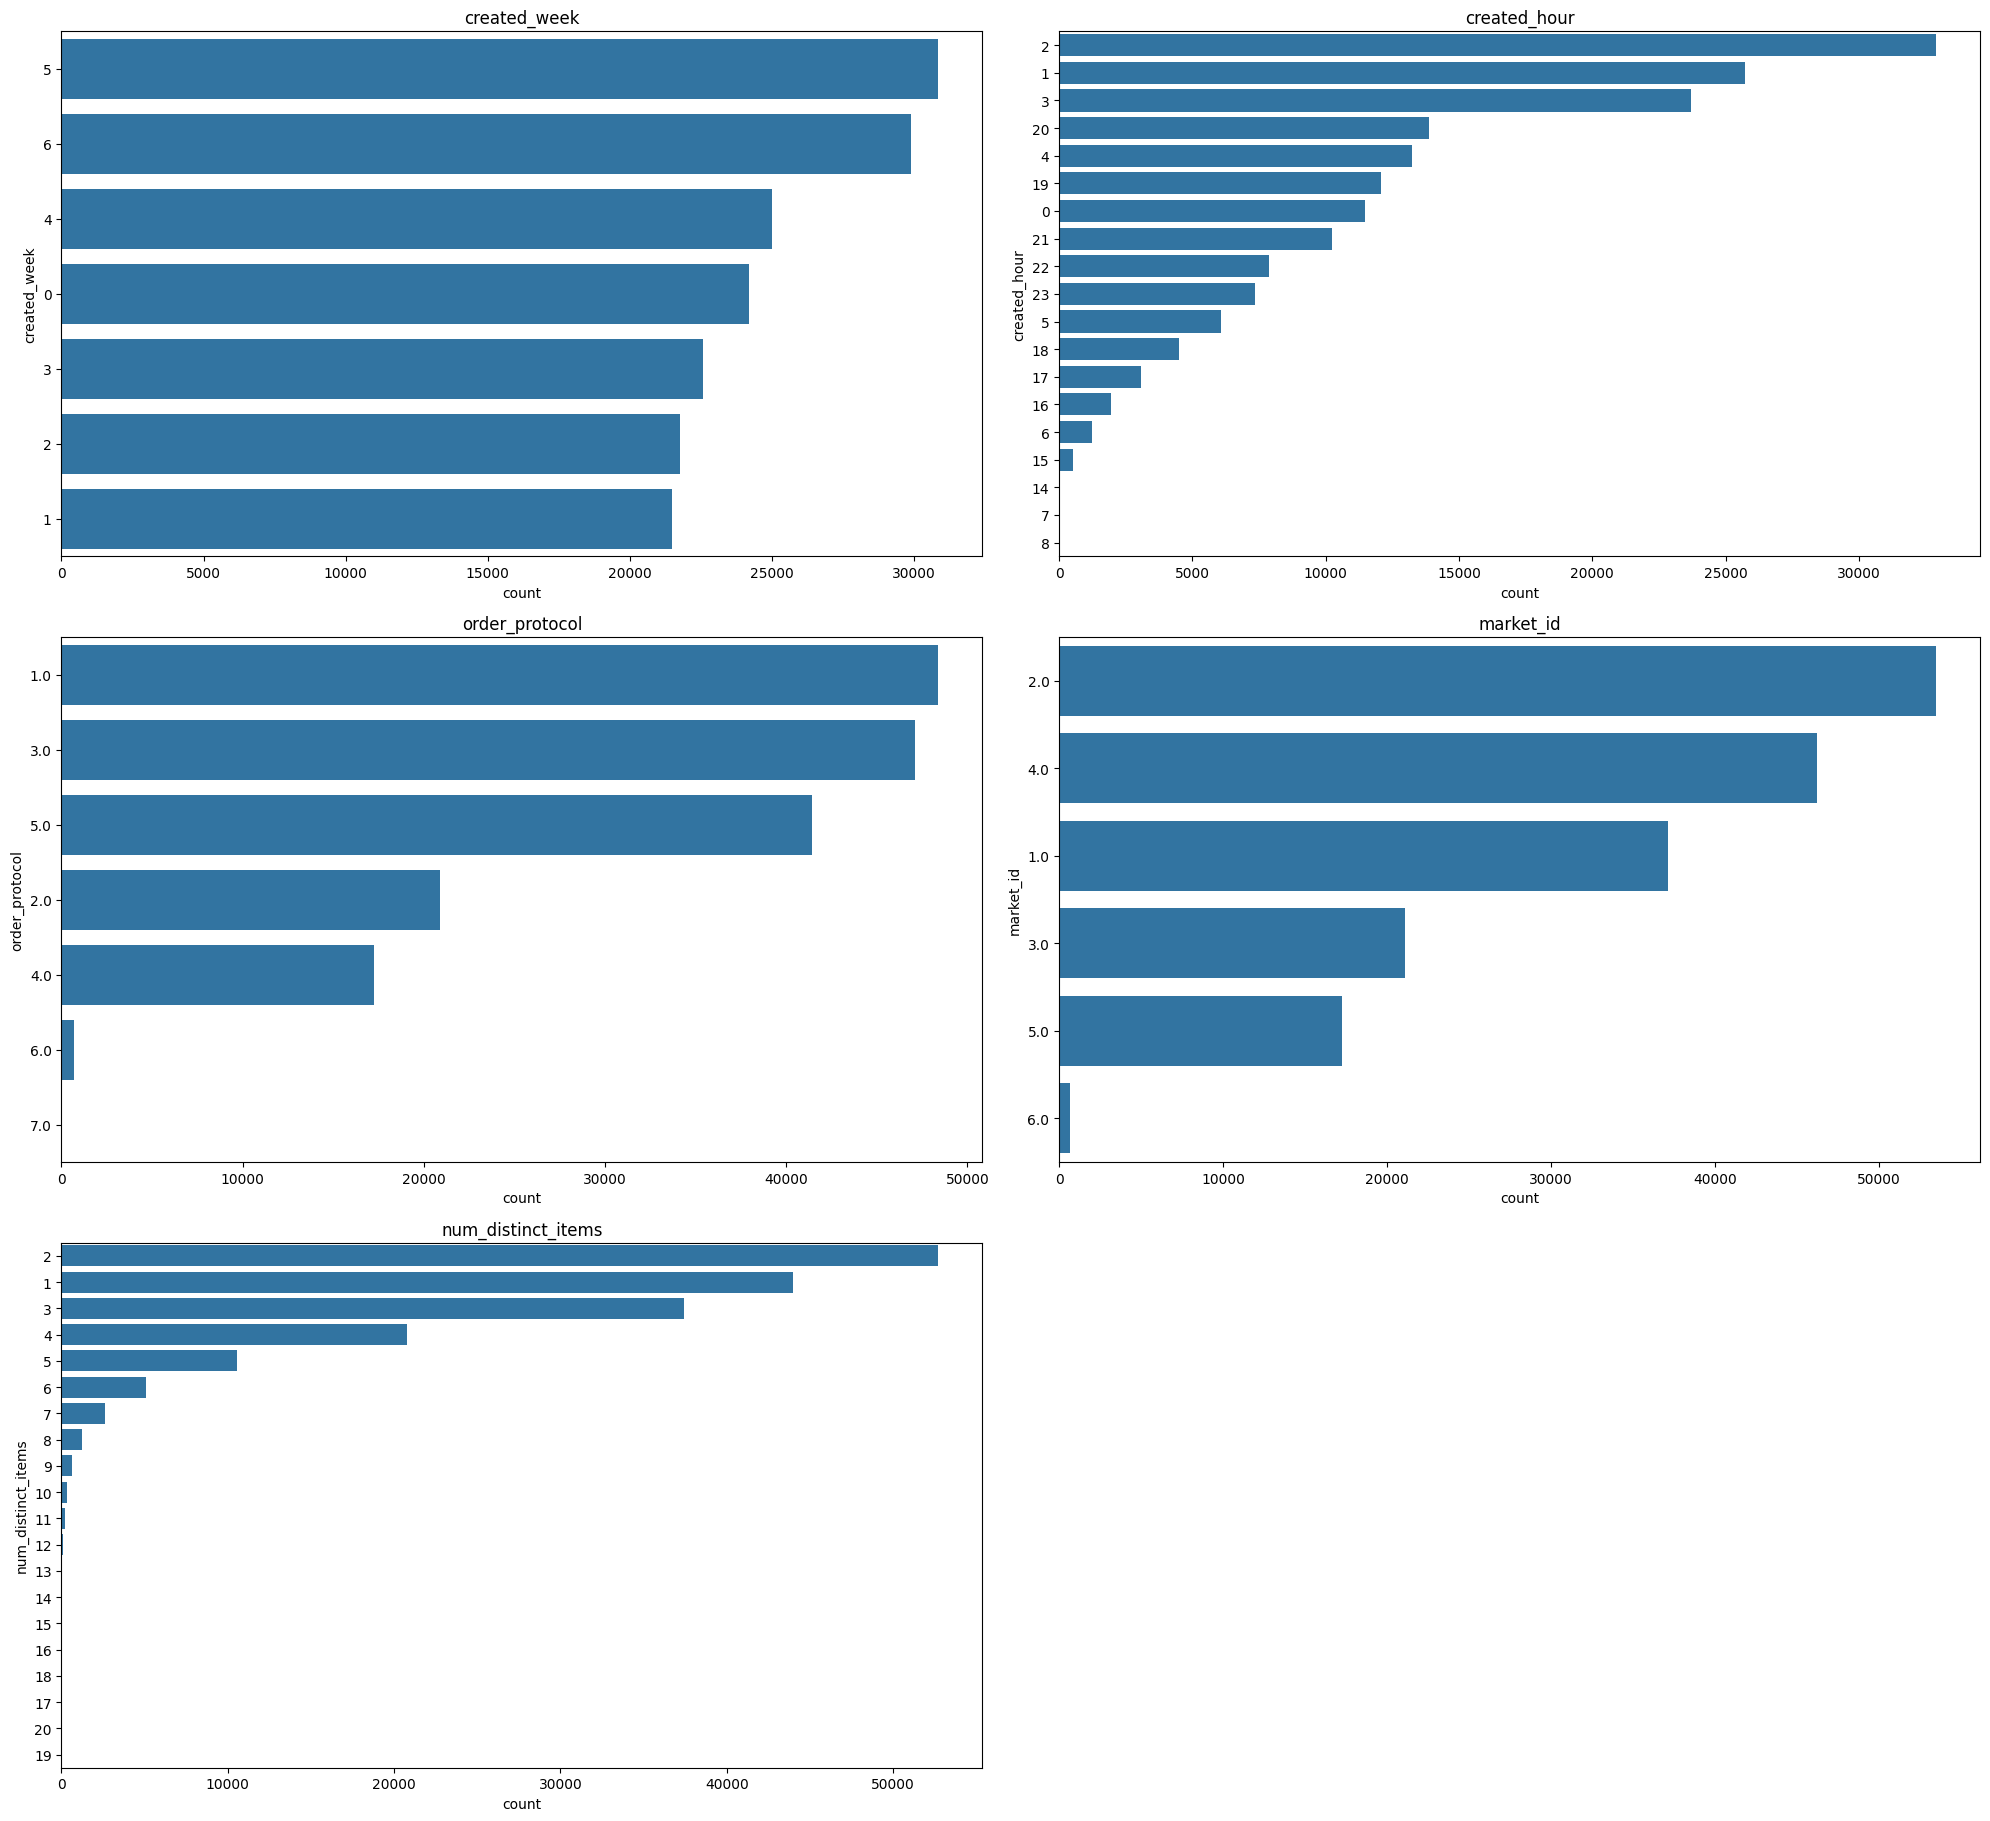

In [ ]:
i=1
plt.figure(figsize=(20,30))
for col in cols1:
  plt.subplot(5,2,i)
  sns.countplot(y=df1[col],order=df1[col].value_counts().index)
  plt.title(col)
  i+=1
plt.tight_layout()
plt.show()

Insights :

5-Friday and 6-Saturady were the highest orders placed days

2pm and 1pm were the hours where highest orders were placed

order protocol 1 is highest which is order was placed using porter

market id 2 was highest were orders were placed to and the followed by market_id 4

Scatterplot

In [ ]:
df1.head()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,created_hour,created_week,delivery_time_minutes
0,1.0,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,22,4,47.0
1,2.0,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,21,1,44.0
2,2.0,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,0,0,55.0
3,1.0,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,3,3,59.0
4,1.0,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,2,1,46.0


In [ ]:
#Scatterplot for created_hour vs delivery_time_minutes

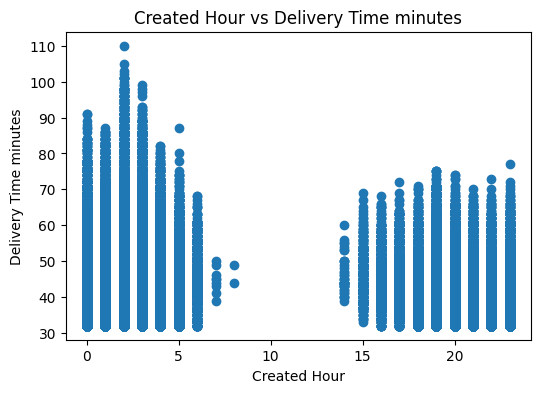

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(x=df1['created_hour'],y=df1['delivery_time_minutes'])
plt.xlabel("Created Hour")
plt.ylabel("Delivery Time minutes")
plt.title("Created Hour vs Delivery Time minutes")
plt.show()

In [ ]:
#scatterplot for created week vs Delivery Time minutes

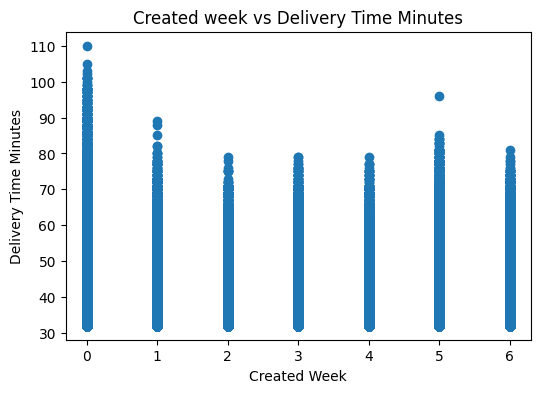

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(x=df1['created_week'],y=df1['delivery_time_minutes'])
plt.xlabel('Created Week')
plt.ylabel('Delivery Time Minutes')
plt.title('Created week vs Delivery Time Minutes')
plt.show()

Heatmap for correlation

<Axes: >

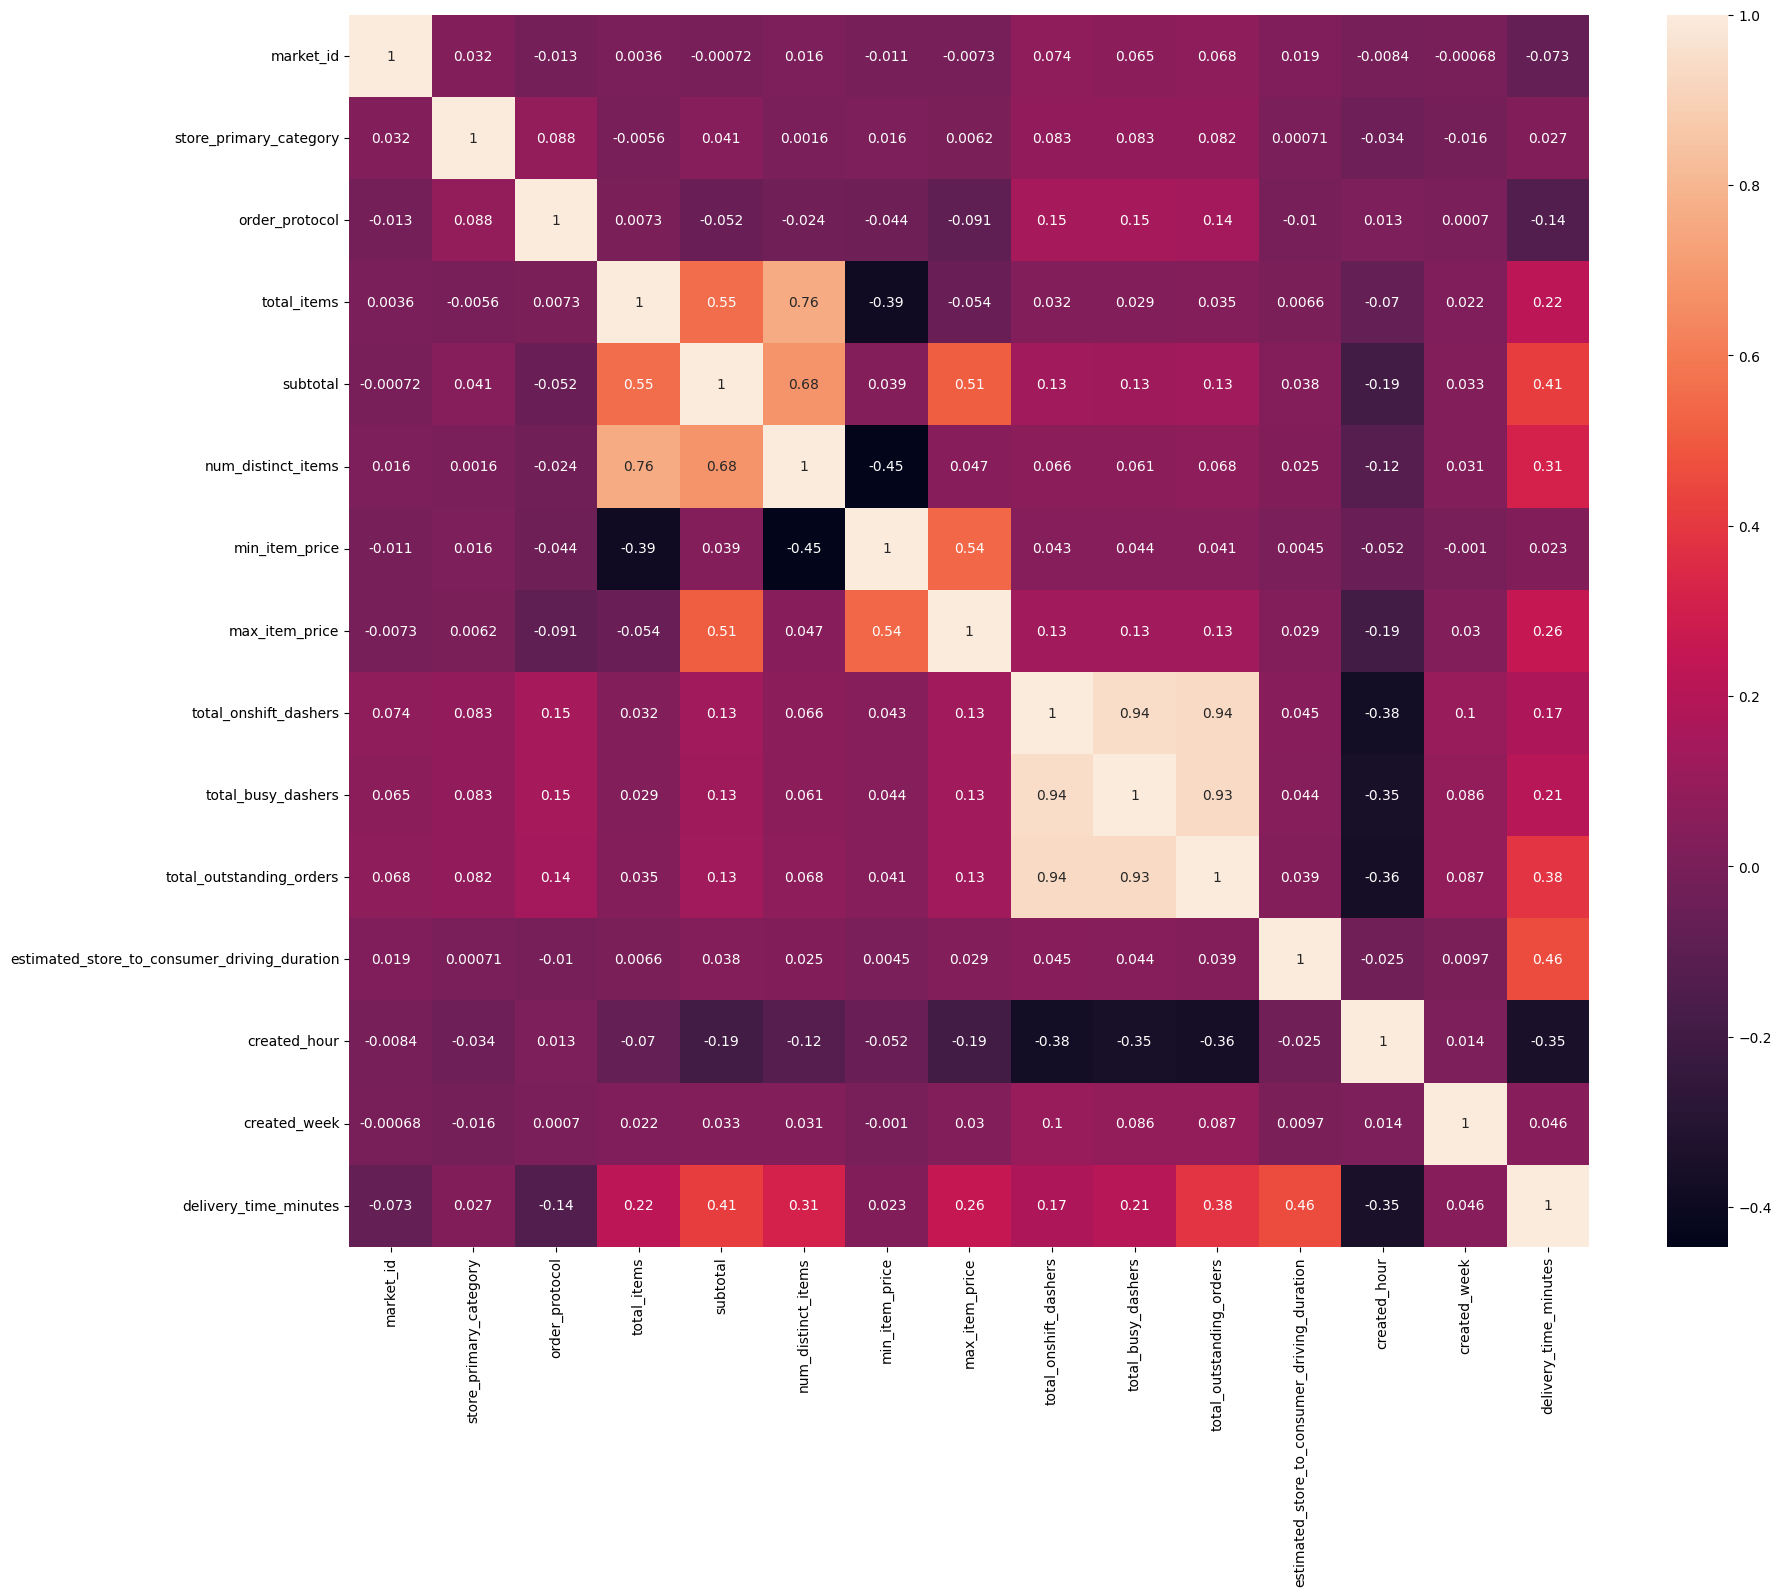

In [ ]:
plt.figure(figsize=(20,16))
sns.heatmap(df1.select_dtypes(['number']).corr(),annot=True)

There is no high correlation between Target delivery time mins and other varibales

drop min_item_price and store_primary_category

In [ ]:
df1.drop(columns=['min_item_price'],inplace=True)

In [ ]:
df1.head()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,created_hour,created_week,delivery_time_minutes
0,1.0,4,1.0,4,3441,4,1239,33.0,14.0,21.0,861.0,22,4,47.0
1,2.0,46,2.0,1,1900,1,1400,1.0,2.0,2.0,690.0,21,1,44.0
2,2.0,36,3.0,4,4771,3,1604,8.0,6.0,18.0,289.0,0,0,55.0
3,1.0,38,1.0,1,1525,1,1525,5.0,6.0,8.0,795.0,3,3,59.0
4,1.0,38,1.0,2,3620,2,2195,5.0,5.0,7.0,205.0,2,1,46.0


Check if the data contains outliers
Removing outliers by any method


Best approach is to remove outliers by IQR + Clipping method

In [ ]:
cols=['total_items', 'subtotal',
       'num_distinct_items', 'max_item_price', 'total_onshift_dashers',
       'total_busy_dashers', 'total_outstanding_orders',
       'estimated_store_to_consumer_driving_duration', 'created_hour',
       'created_week', 'delivery_time_minutes']

In [ ]:
for col in cols:
  Q1=df1[col].quantile(0.25)
  Q3=df1[col].quantile(0.75)

  IQR=Q3-Q1

  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR

  df1[col]=np.clip(df1[col],lower,upper)


In [ ]:
df1.shape

(175777, 14)

No loss of data by using clipping method

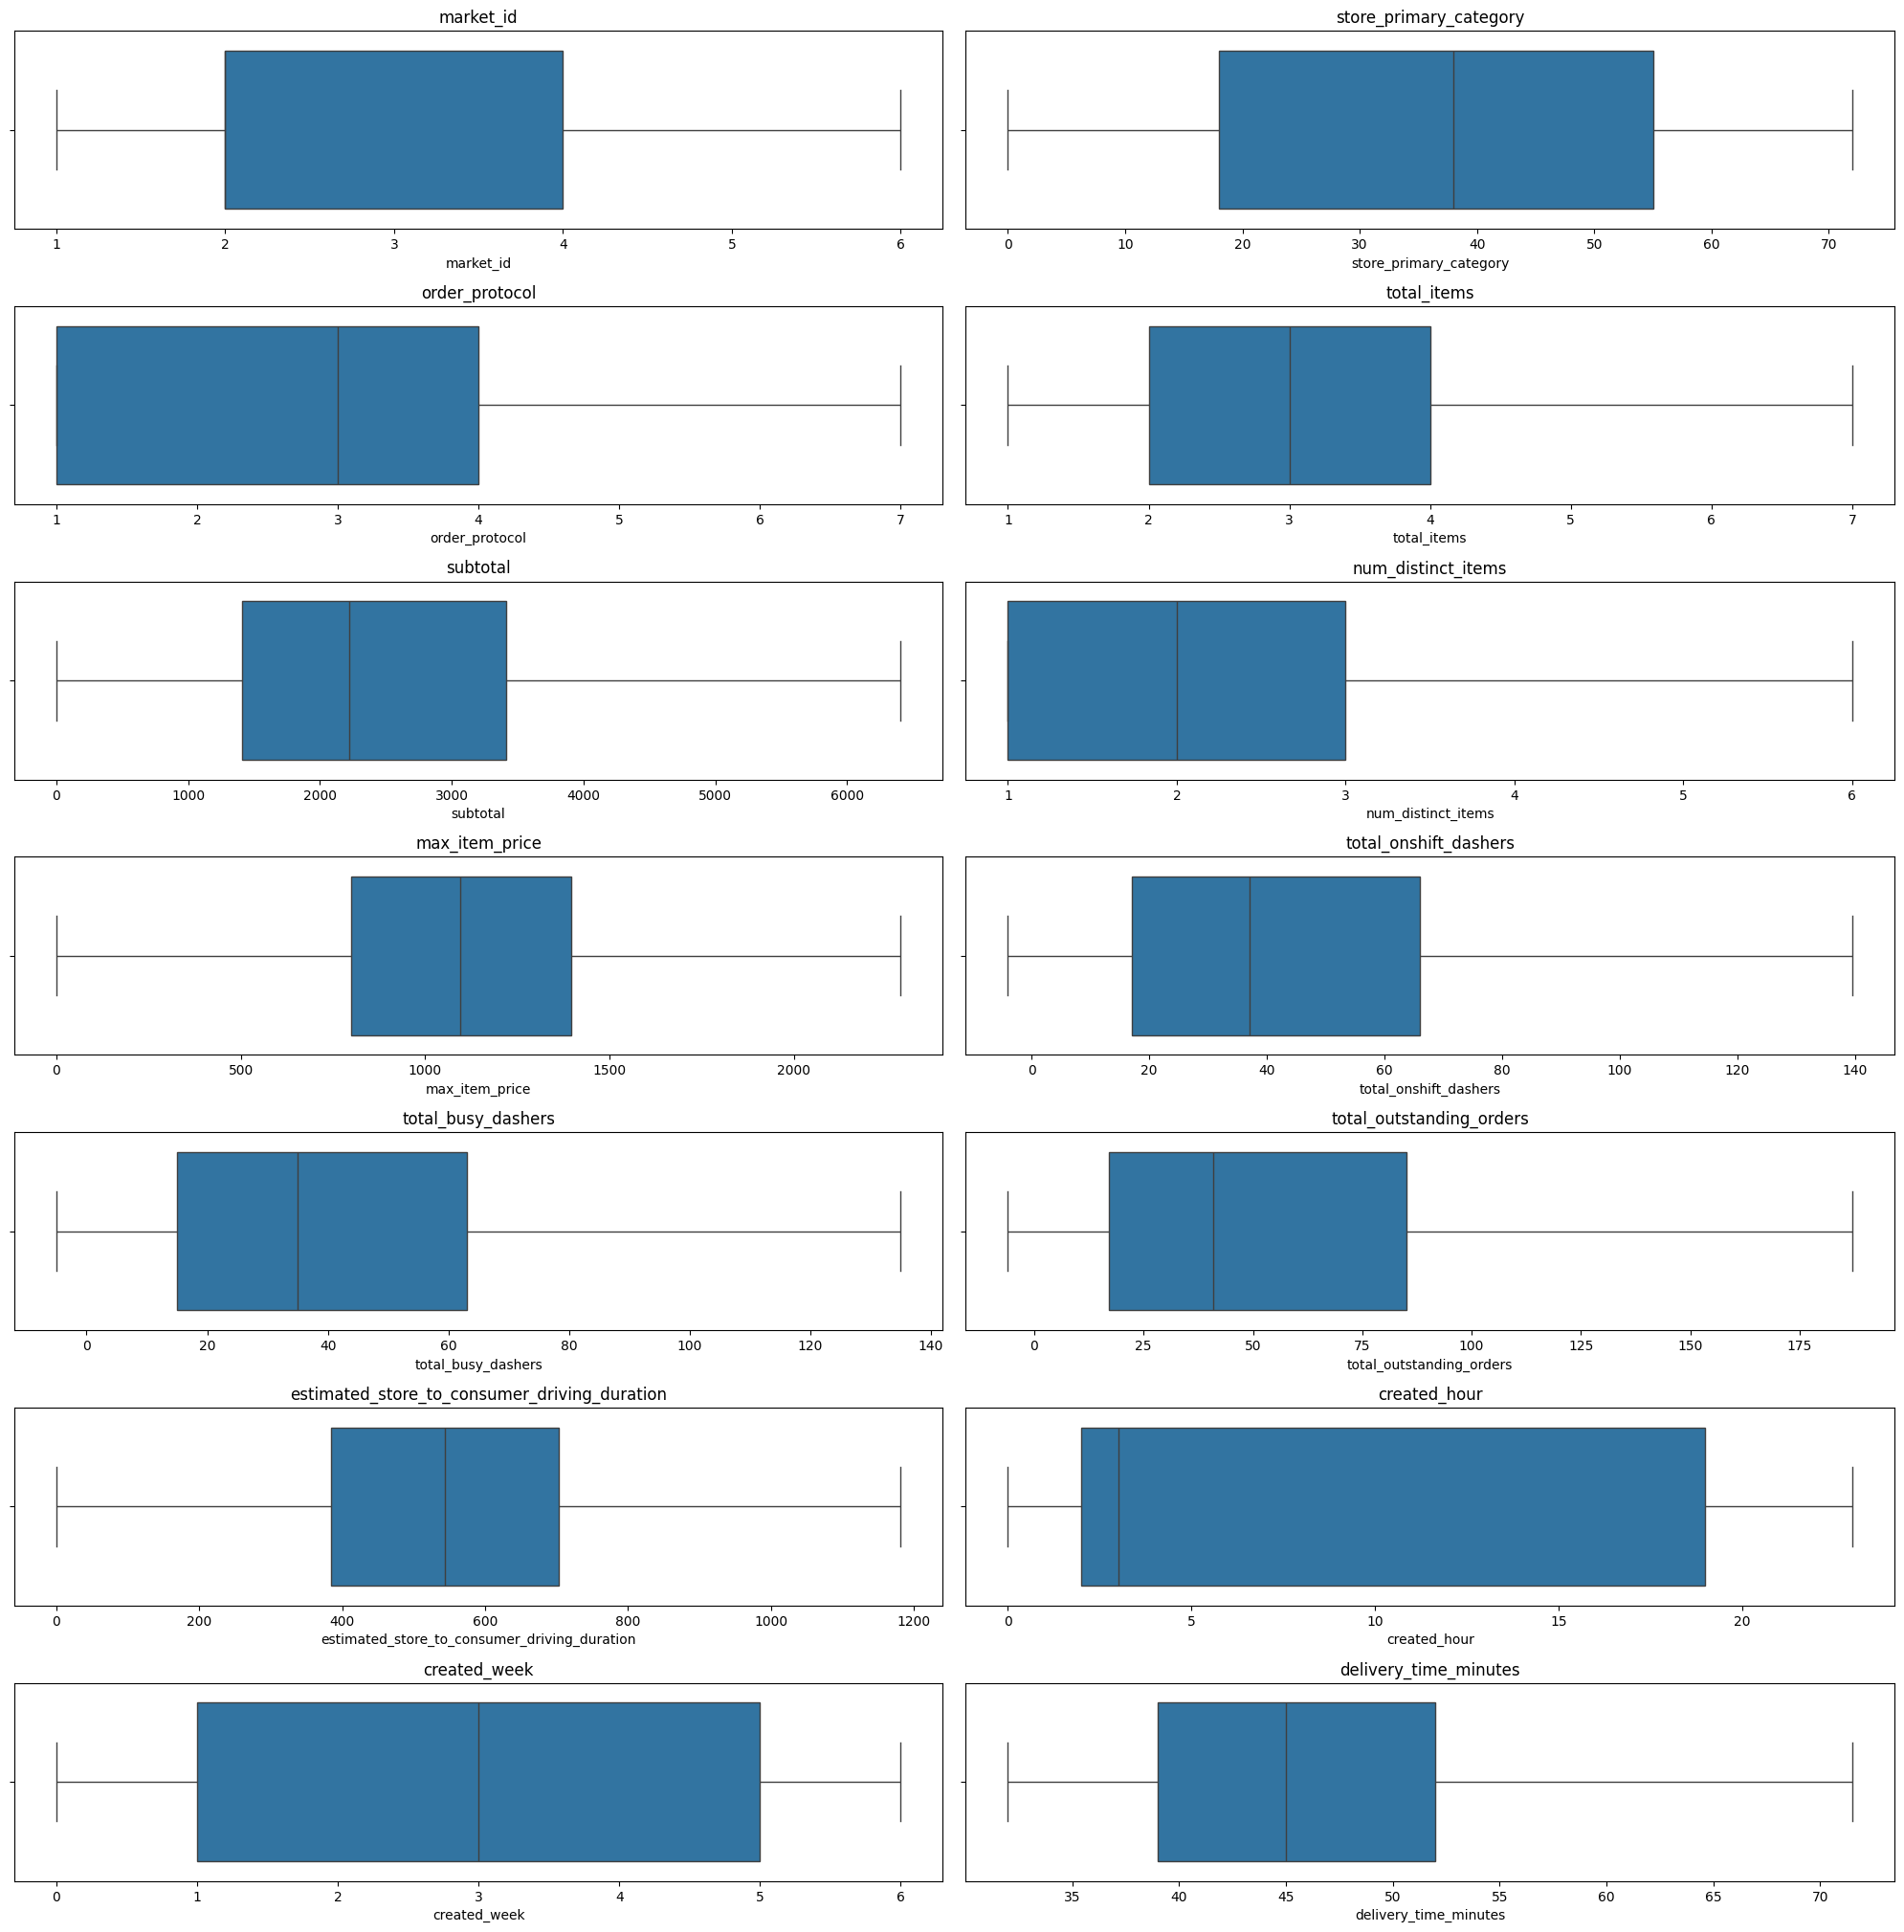

In [ ]:
i=1
plt.figure(figsize=(20,40))
for col in df1.columns:
  plt.subplot(len(df1.columns),2,i)
  sns.boxplot(x=df1[col])
  plt.title(col)
  i+=1
plt.tight_layout()
plt.show()

Outliers have been treated and there are no outliers

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   store_primary_category                        175777 non-null  int64  
 2   order_protocol                                175777 non-null  float64
 3   total_items                                   175777 non-null  int64  
 4   subtotal                                      175777 non-null  int64  
 5   num_distinct_items                            175777 non-null  int64  
 6   max_item_price                                175777 non-null  int64  
 7   total_onshift_dashers                         175777 non-null  float64
 8   total_busy_dashers                            175777 non-null  float64
 9   total_outstanding_orders                      17

We have market_id and order protocol one hot encoding

In [ ]:
df2=df1.copy()

In [ ]:
df2['market_id']=df2['market_id'].astype('int')
df2['order_protocol']=df2['order_protocol'].astype('int')

df2=pd.get_dummies(df2,columns=['market_id','order_protocol'],drop_first=True,dtype='int')

In [ ]:
df2.head()

,store_primary_category,total_items,subtotal,num_distinct_items,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,created_hour,...,market_id_3,market_id_4,market_id_5,market_id_6,order_protocol_2,order_protocol_3,order_protocol_4,order_protocol_5,order_protocol_6,order_protocol_7
0,4,4,3441,4,1239,33.0,14.0,21.0,861.0,22,...,0,0,0,0,0,0,0,0,0,0
1,46,1,1900,1,1400,1.0,2.0,2.0,690.0,21,...,0,0,0,0,1,0,0,0,0,0
2,36,4,4771,3,1604,8.0,6.0,18.0,289.0,0,...,0,0,0,0,0,1,0,0,0,0
3,38,1,1525,1,1525,5.0,6.0,8.0,795.0,3,...,0,0,0,0,0,0,0,0,0,0
4,38,2,3620,2,2195,5.0,5.0,7.0,205.0,2,...,0,0,0,0,0,0,0,0,0,0


Regression with neural networks

Split the data into train and test

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=df2.drop(columns=['delivery_time_minutes'])
y=df2['delivery_time_minutes']

In [ ]:
X_train_val,X_test,y_train_val,y_test=train_test_split(X,y,test_size=0.1,random_state=42)
X_train,X_val,y_train,y_val=train_test_split(X_train_val,y_train_val,test_size=0.1,random_state=42)

print("Train :",X_train.shape,y_train.shape)
print("Test  :",X_test.shape,y_test.shape)
print("Validation :",X_val.shape,y_val.shape)

Train : (142379, 22) (142379,)
Test  : (17578, 22) (17578,)
Validation : (15820, 22) (15820,)


Target encoding on store_primary_category

In [ ]:
!pip install category-encoders

In [ ]:
#Target encoding the categorical variable
from category_encoders import TargetEncoder

target=TargetEncoder(cols=['store_primary_category'])
X_train=target.fit_transform(X_train,y_train)
X_test=target.transform(X_test)
X_val=target.transform(X_val)

In [ ]:
X_train.head()

,store_primary_category,total_items,subtotal,num_distinct_items,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,created_hour,...,market_id_3,market_id_4,market_id_5,market_id_6,order_protocol_2,order_protocol_3,order_protocol_4,order_protocol_5,order_protocol_6,order_protocol_7
144785,42.924071,2,1550,2,1100,2.0,2.0,4.0,583.0,19,...,0,0,0,0,1,0,0,0,0,0
119522,45.937538,1,1718,1,1299,52.0,73.0,104.0,623.0,3,...,0,1,0,0,0,0,0,0,0,0
136610,45.755885,4,4645,4,1250,26.0,27.0,40.0,683.0,19,...,0,0,0,0,0,0,0,1,0,0
168575,44.365940,1,1450,1,1450,14.0,16.0,17.0,336.0,18,...,0,1,0,0,1,0,0,0,0,0
104438,47.212587,2,1420,1,710,58.0,57.0,62.0,520.0,3,...,0,0,0,0,0,0,1,0,0,0


Scaling the data using StandardScaler with mean = 0 and std = 1

In [ ]:
#scaling

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_val=scaler.transform(X_val)

In [ ]:
X_train

array([[-1.69948375, -0.57808726, -0.68897179, ..., -0.55687666,
        -0.06232967, -0.01026468],
       [-0.10266113, -1.14770107, -0.57928655, ..., -0.55687666,
        -0.06232967, -0.01026468],
       [-0.19891864,  0.56114035,  1.33171761, ...,  1.79572977,
        -0.06232967, -0.01026468],
       ...,
       [-0.86678406, -0.00847345, -0.88679695, ...,  1.79572977,
        -0.06232967, -0.01026468],
       [-0.10266113, -1.14770107,  0.27665006, ..., -0.55687666,
        -0.06232967, -0.01026468],
       [ 0.02017935, -1.14770107, -0.85545831, ..., -0.55687666,
        -0.06232967, -0.01026468]])

Training a random forest model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(max_depth=10,n_estimators=450)
rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=10, n_estimators=450)

In [ ]:
rf.score(X_train,y_train)

0.849082524519933

In [ ]:
rf.score(X_test,y_test)

0.838846924248862

Random Forest let's proceed with Neural Network  model

Creating a simple neural network

Trying different configurations

Understanding different activation functions, optimizers and other hyperparameters.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

Let's do for activation fuction tanh and optimizer SGD

In [ ]:
def baseline_model():
  model=Sequential()
  model.add(Dense(512,activation='tanh',input_shape=(X_train.shape[1],)))
  model.add(Dense(128,activation='tanh'))
  model.add(Dense(64,activation='tanh'))
  model.add(Dense(32,activation='tanh'))
  model.add(Dense(1,activation='linear'))
  return model

In [ ]:
model_tanh=baseline_model()
model_tanh.compile(optimizer=tf.keras.optimizers.SGD(),
                   loss='mse',
                   metrics=['mse','mae'])
history=model_tanh.fit(X_train,y_train,validation_data=[X_val,y_val],epochs=10,batch_size=256,verbose=1)

Epoch 1/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 176.8657 - mae: 7.4673 - mse: 176.8657 - val_loss: 5.5840 - val_mae: 1.7896 - val_mse: 5.5840
Epoch 2/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4.8684 - mae: 1.5837 - mse: 4.8684 - val_loss: 3.3266 - val_mae: 1.2443 - val_mse: 3.3266
Epoch 3/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 3.1785 - mae: 1.2048 - mse: 3.1785 - val_loss: 6.6071 - val_mae: 1.8583 - val_mse: 6.6071
Epoch 4/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2.6515 - mae: 1.0737 - mse: 2.6515 - val_loss: 5.2068 - val_mae: 1.7021 - val_mse: 5.2068
Epoch 5/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 2.3808 - mae: 1.0023 - mse: 2.3808 - val_loss: 2.1816 - val_mae: 0.9617 - val_mse: 2.1816
Epoch 6/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 2.0378 - mae: 0.8880 - mse: 2.0378 - val_loss: 2.3403 - val_mae: 1.1155 - val_mse: 2.3403
Epoch 7/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.0438 - mae: 0.9112 - mse: 2.0438 -

For activation tanh let's do optimizer SGD momentum

In [ ]:
model_tanh=baseline_model()
model_tanh.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01,momentum=0.6),
                   loss='mse',
                   metrics=['mse','mae'])
history=model_tanh.fit(X_train,y_train,validation_data=[X_val,y_val],epochs=10,batch_size=256,verbose=1)

Epoch 1/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 132.0520 - mae: 6.4441 - mse: 132.0520 - val_loss: 4.6149 - val_mae: 1.5766 - val_mse: 4.6149
Epoch 2/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 3.5845 - mae: 1.2969 - mse: 3.5845 - val_loss: 2.8182 - val_mae: 1.1705 - val_mse: 2.8182
Epoch 3/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.6374 - mae: 1.0728 - mse: 2.6374 - val_loss: 2.7751 - val_mae: 1.1904 - val_mse: 2.7751
Epoch 4/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 2.1665 - mae: 0.9521 - mse: 2.1665 - val_loss: 2.4218 - val_mae: 0.9666 - val_mse: 2.4218
Epoch 5/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 2.0170 - mae: 0.8970 - mse: 2.0170 - val_loss: 3.1624 - val_mae: 1.1754 - val_mse: 3.1624
Epoch 6/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.9306 - mae: 0.8676 - mse: 1.9306 - val_loss: 2.2396 - val_mae: 0.8744 - val_mse: 2.2396
Epoch 7/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.8517 - mae: 0.8360 - mse: 1.8517 -

Loss of SGD momentum is less than SGD

Activation function tanh and optimizer with RMSProp

In [ ]:
model_rms=baseline_model()
model_rms.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001,rho=0.95),
                  loss='mse',
                  metrics=['mse','mae'])
history=model_rms.fit(X_train,y_train,validation_data=[X_train,y_train],batch_size=256,epochs=10,verbose=1)

Epoch 1/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1272.3976 - mae: 34.0099 - mse: 1272.3976 - val_loss: 498.7459 - val_mae: 19.8776 - val_mse: 498.7459
Epoch 2/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 369.1271 - mae: 15.8249 - mse: 369.1271 - val_loss: 147.3018 - val_mae: 8.0014 - val_mse: 147.3018
Epoch 3/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 143.4384 - mae: 7.9482 - mse: 143.4384 - val_loss: 142.6778 - val_mae: 7.9669 - val_mse: 142.6778
Epoch 4/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 143.9454 - mae: 7.9622 - mse: 143.9454 - val_loss: 141.5729 - val_mae: 7.9532 - val_mse: 141.5729
Epoch 5/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 142.0886 - mae: 7.9521 - mse: 142.0886 - val_loss: 140.1486 - val_mae: 7.9439 - val_mse: 140.1486
Epoch 6/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 140.9440 - mae: 7.9521 - mse: 140.9440 - val_loss: 138.9104 - val_mae: 7.9438 - val_mse: 138.9104
Epoch 7/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 8m

Activation Tanh and optimizer Adam

In [ ]:
model_adam=baseline_model()
model_adam.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.95),
                   loss='mse',
                   metrics=['mae','mse'])
history=model_adam.fit(X_train,y_train,validation_data=[X_val,y_val],epochs=10,batch_size=256,verbose=1)

Epoch 1/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1403.8107 - mae: 35.9353 - mse: 1403.8107 - val_loss: 531.9600 - val_mae: 21.1651 - val_mse: 531.9600
Epoch 2/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 372.1501 - mae: 16.6960 - mse: 372.1501 - val_loss: 96.9383 - val_mae: 7.5409 - val_mse: 96.9383
Epoch 3/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 86.8217 - mae: 7.4027 - mse: 86.8217 - val_loss: 86.0836 - val_mae: 7.4217 - val_mse: 86.0836
Epoch 4/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 83.6942 - mae: 7.3894 - mse: 83.6942 - val_loss: 85.4522 - val_mae: 7.4065 - val_mse: 85.4522
Epoch 5/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 60.6658 - mae: 5.6349 - mse: 60.6658 - val_loss: 6.5143 - val_mae: 1.3024 - val_mse: 6.5143
Epoch 6/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 3.9598 - mae: 1.0808 - mse: 3.9598 - val_loss: 2.5635 - val_mae: 0.7854 - val_mse: 2.5635
Epoch 7/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2.0422 - ma

Creating a Baseline model with activation fucntion Relu and different optimizers

He _uniform is  weight_initializer best for Relu activation , we use Relu activation because the Back propagation is smooth without vanishing gradients

In [ ]:
def create_model():
  model=Sequential()
  model.add(Dense(512,activation='relu',kernel_initializer='he_uniform',input_shape=(X_train.shape[1],)))
  model.add(Dense(128,activation='relu',kernel_initializer='he_uniform'))
  model.add(Dense(64,activation='relu',kernel_initializer='he_uniform'))
  model.add(Dense(32,activation='relu',kernel_initializer='he_uniform'))
  model.add(Dense(1,activation='linear'))
  return model

Activation Relu with SGD

In [ ]:
model_sgd=create_model()
model_sgd.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.0005),
                  loss='mse',
                  metrics=['mse','mae'])
history=model_sgd.fit(X_train,y_train,validation_data=[X_val,y_val],epochs=10,batch_size=256,verbose=1)

Epoch 1/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1013.6496 - mae: 25.5228 - mse: 1013.6496 - val_loss: 8.3292 - val_mae: 2.1787 - val_mse: 8.3292
Epoch 2/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 15.5998 - mae: 3.1315 - mse: 15.5998 - val_loss: 10.0863 - val_mae: 2.5598 - val_mse: 10.0863
Epoch 3/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.1341 - mae: 2.1486 - mse: 8.1341 - val_loss: 6.8633 - val_mae: 1.9514 - val_mse: 6.8633
Epoch 4/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 7.1272 - mae: 1.9908 - mse: 7.1272 - val_loss: 5.0536 - val_mae: 1.6798 - val_mse: 5.0536
Epoch 5/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 5.3827 - mae: 1.6964 - mse: 5.3827 - val_loss: 4.4551 - val_mae: 1.4701 - val_mse: 4.4551
Epoch 6/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 4.5755 - mae: 1.5339 - mse: 4.5755 - val_loss: 3.8362 - val_mae: 1.3913 - val_mse: 3.8362
Epoch 7/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 4.2063 - mae: 1.4467 - mse:

Activation Relu with SGD momentum

In [ ]:
model_sgd_momentum=create_model()
model_sgd_momentum.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.0005,momentum=0.6),
                           loss='mse',
                           metrics=['mse','mae'])
model_sgd_momentum.fit(X_train,y_train,validation_data=[X_val,y_val],batch_size=256,epochs=10,verbose=1)

Epoch 1/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1278.3397 - mae: 32.7537 - mse: 1278.3397 - val_loss: 233.3291 - val_mae: 12.4246 - val_mse: 233.3291
Epoch 2/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 169.1297 - mae: 10.1126 - mse: 169.1297 - val_loss: 92.9599 - val_mae: 7.4609 - val_mse: 92.9599
Epoch 3/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 88.7253 - mae: 7.3948 - mse: 88.7253 - val_loss: 84.1166 - val_mae: 7.3456 - val_mse: 84.1166
Epoch 4/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 83.6608 - mae: 7.3613 - mse: 83.6608 - val_loss: 83.4815 - val_mae: 7.3776 - val_mse: 83.4815
Epoch 5/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 83.0083 - mae: 7.3624 - mse: 83.0083 - val_loss: 69.2906 - val_mae: 6.4180 - val_mse: 69.2906
Epoch 6/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 50.9230 - mae: 4.9264 - mse: 50.9230 - val_loss: 30.7873 - val_mae: 3.3910 - val_mse: 30.7873
Epoch 7/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 27.

SGD momentum has lower loss compared to SGD

Activation Relu and optimizer RMSprop

In [ ]:
model_rms=create_model()
model_rms.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0005,rho=0.85),
                  loss='mse',
                  metrics=['mse','mae'])
model_rms.fit(X_train,y_train,validation_data=[X_val,y_val],epochs=10,batch_size=256,verbose=1)

Epoch 1/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 285.9908 - mae: 9.5301 - mse: 285.9908 - val_loss: 19.0198 - val_mae: 3.5497 - val_mse: 19.0198
Epoch 2/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 10.3730 - mae: 2.4808 - mse: 10.3730 - val_loss: 5.6300 - val_mae: 1.7356 - val_mse: 5.6300
Epoch 3/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 7.4660 - mae: 2.0885 - mse: 7.4660 - val_loss: 4.2078 - val_mae: 1.4206 - val_mse: 4.2078
Epoch 4/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.9689 - mae: 1.8248 - mse: 5.9689 - val_loss: 6.2202 - val_mae: 1.9175 - val_mse: 6.2202
Epoch 5/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.1570 - mae: 1.7006 - mse: 5.1570 - val_loss: 4.9516 - val_mae: 1.7284 - val_mse: 4.9516
Epoch 6/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4.5343 - mae: 1.5784 - mse: 4.5343 - val_loss: 3.5416 - val_mae: 1.3341 - val_mse: 3.5416
Epoch 7/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 4.1062 - mae: 1.4758 - mse: 4.10

In [ ]:
model_adam=create_model()
model_adam.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01,beta_1=0.9,beta_2=0.95),
                  loss='mse',
                  metrics=['mse','mae'])
model_adam.fit(X_train,y_train,validation_data=[X_val,y_val],epochs=10,batch_size=256,verbose=1)

Epoch 1/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 141.0790 - mae: 5.0227 - mse: 141.0790 - val_loss: 7.6763 - val_mae: 2.1848 - val_mse: 7.6763
Epoch 2/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 3.7127 - mae: 1.3219 - mse: 3.7127 - val_loss: 3.8074 - val_mae: 1.4294 - val_mse: 3.8074
Epoch 3/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2.7549 - mae: 1.0973 - mse: 2.7549 - val_loss: 2.1060 - val_mae: 0.8976 - val_mse: 2.1060
Epoch 4/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2.3368 - mae: 0.9979 - mse: 2.3368 - val_loss: 2.0129 - val_mae: 0.8583 - val_mse: 2.0129
Epoch 5/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 2.2465 - mae: 0.9412 - mse: 2.2465 - val_loss: 2.4199 - val_mae: 0.8916 - val_mse: 2.4199
Epoch 6/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2.0400 - mae: 0.8896 - mse: 2.0400 - val_loss: 4.7316 - val_mae: 1.6830 - val_mse: 4.7316
Epoch 7/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 2.0434 - mae: 0.9126 - mse: 2.0434 -

Adam optimizer work better that all other optimizer

The optimal NN architecture using Keras tuner , to get the no hidden  of layers , no of nuerons and activation Function

In [ ]:
!pip install keras-tuner

In [ ]:
import keras_tuner

In [ ]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras .layers import BatchNormalization,Dropout

In [ ]:
def build_model(hp):

  model=Sequential()
  l2=tf.keras.regularizers.L2(l2=1e-4)
  model.add(Dense(units=hp.Int('units_0',min_value=8,max_value=256,step=16),activation=hp.Choice('activation_0',['tanh','relu']),input_shape=(X_train.shape[1],),
                  kernel_initializer='he_uniform',kernel_regularizer=l2))
  model.add(BatchNormalization())
  model.add(Dropout(0.2))

  num_layers=hp.Int('layers',1,5)
  for i in range(1,num_layers):
    model.add(Dense(units=hp.Int(f'units_{i}',min_value=8,max_value=256,step=16),activation=hp.Choice(f'activation_{i}',['tanh','relu']),
                    kernel_initializer='he_uniform',kernel_regularizer=l2))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

  model.add(Dense(1,activation='linear'))

  lr=hp.Choice('learning_rate',[1e-2,1e-3,1e-4,1e-5])
  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                loss='mse',
                metrics=['mse','mae'])
  return model

In [ ]:
tuner=keras_tuner.RandomSearch(build_model,objective='val_loss',max_trials=10)

Reloading Tuner from ./untitled_project/tuner0.json


In [ ]:
tuner.search(X_train,y_train,validation_data=[X_val,y_val],epochs=10)

Rebuild the model Using best Hyperparameters obtained from keras tuner

In [ ]:
best_hp=tuner.get_best_hyperparameters()[0]

model=tuner.hypermodel.build(best_hp)

In [ ]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 88)             │         2,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 88)             │           352 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 88)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 168)            │        14,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 168)            │           672 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 168)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │           169 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,169 (70.97 KB)

 Trainable params: 17,657 (68.97 KB)

 Non-trainable params: 512 (2.00 KB)

plot the diagram for model

In [ ]:
from tensorflow.keras.utils import plot_model

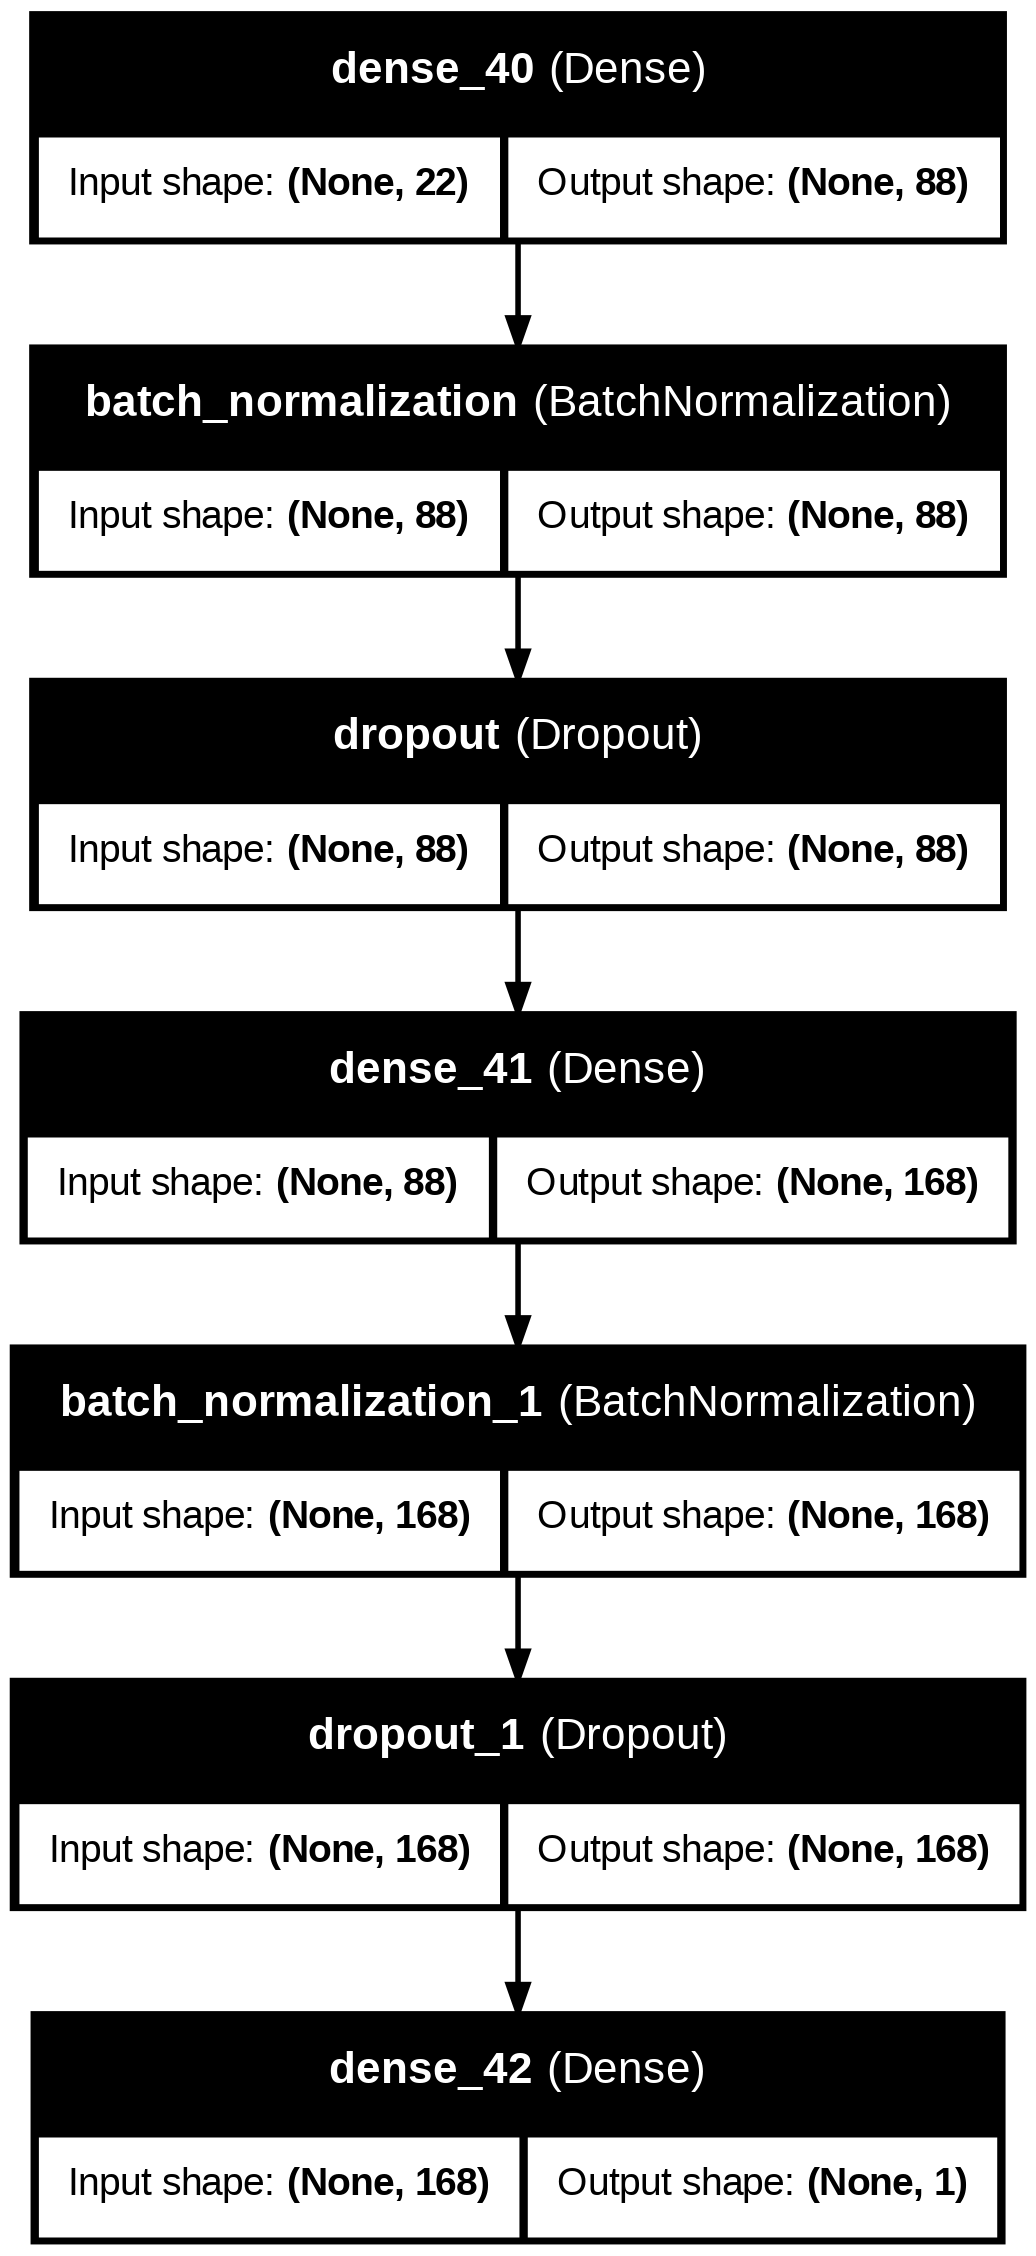

In [ ]:
plot_model(model,show_shapes=True,show_layer_names=True)

Let's the Eppchs to train using EarlyStopping and ModelCheckpoints

Early stoping the model stops the training at epoch where the val_loss or accuracy is reducing

Modelcheckoints stores the best model weights and parametrs where model was stopped


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint

In [ ]:
early=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)
check=ModelCheckpoint('h2.keras',monitor='val_loss',save_best_only=True,mode='min')

In [ ]:
history=model.fit(X_train,y_train,validation_data=[X_val,y_val],epochs=30,batch_size=128,verbose=1,callbacks=[early,check])

Epoch 1/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 1068.5474 - mae: 27.3140 - mse: 1068.4954 - val_loss: 6.5989 - val_mae: 1.9227 - val_mse: 6.5470
Epoch 2/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 20.7241 - mae: 3.5489 - mse: 20.6722 - val_loss: 4.6006 - val_mae: 1.5439 - val_mse: 4.5490
Epoch 3/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 14.1670 - mae: 2.9005 - mse: 14.1154 - val_loss: 3.5705 - val_mae: 1.2956 - val_mse: 3.5192
Epoch 4/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 11.1976 - mae: 2.5442 - mse: 11.1463 - val_loss: 3.2790 - val_mae: 1.2359 - val_mse: 3.2279
Epoch 5/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 9.6281 - mae: 2.3472 - mse: 9.5771 - val_loss: 2.7515 - val_mae: 1.0596 - val_mse: 2.7008
Epoch 6/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 8.6591 - mae: 2.2184 - mse: 8.6083 - val_loss: 2.7005 - val_mae: 1.0531 - val_mse: 2.6500
Epoch 7/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 8.0818 - m

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
best_model=load_model('h2.keras')
best_model

<Sequential name=sequential_8, built=True>

Best model weights after early stopping and Model checkpoint

Plotting the losses

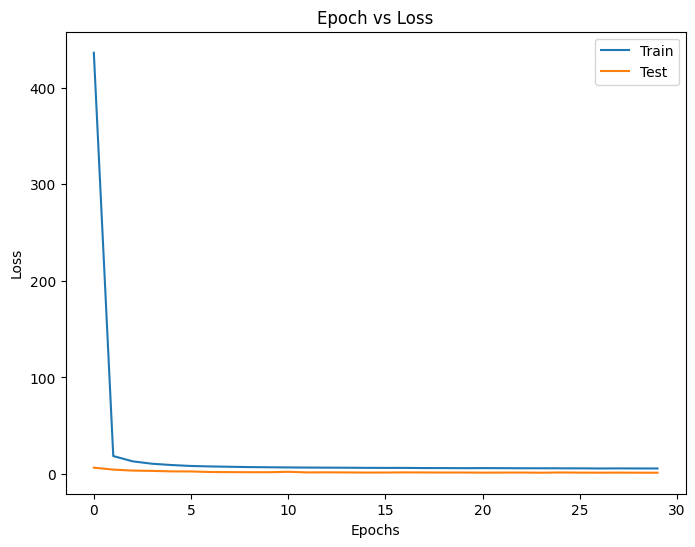

In [ ]:
epochs=history.epoch
loss=history.history['loss']
val_loss=history.history['val_loss']
plt.figure(figsize=(8,6))
plt.plot(epochs,loss,label='Train')
plt.plot(epochs,val_loss,label='Test')
plt.title("Epoch vs Loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

Evaluation of the best_model

Train Data evaluation

In [ ]:
loss,mae,mse=best_model.evaluate(X_train,y_train)
print("Train data")
print('loss :',loss)
print('mean_absolute_error :',mae)
print("mean_squared_error :",mse)
print("root_mean_squared_error :",np.sqrt(mse))


4450/4450 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 1.2871 - mae: 0.6092 - mse: 1.2250
Train data
loss : 1.2947397232055664
mean_absolute_error : 1.2326894998550415
mean_squared_error : 0.6114779114723206
root_mean_squared_error : 0.7819705310766644


Test Data Evaluation

In [ ]:
loss,mae,mse=best_model.evaluate(X_test,y_test)
print("Test data")
print('loss :',loss)
print('mean_absolute_error :',mae)
print("mean_squared_error :",mse)
print("root_mean_squared_error :",np.sqrt(mse))

550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.3708 - mae: 0.6202 - mse: 1.3088
Test data
loss : 1.29105806350708
mean_absolute_error : 1.2290096282958984
mean_squared_error : 0.6131104826927185
root_mean_squared_error : 0.7830137180744144


Validation Data Evaluation

In [ ]:
loss,mae,mse=best_model.evaluate(X_val,y_val)
print("Validation data")
print('loss :',loss)
print('mean_absolute_error :',mae)
print("mean_squared_error :",mse)
print("root_mean_squared_error :",np.sqrt(mse))

495/495 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3591 - mae: 0.6287 - mse: 1.2970
Validation data
loss : 1.3778162002563477
mean_absolute_error : 1.3157700300216675
mean_squared_error : 0.6276339292526245
root_mean_squared_error : 0.7922335067722297


Plotting the losses and checking the accuracy of the model

In [ ]:
history.history.keys()

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse'])

Accuracy of best model . since it is Regression let's use R2_score

In [ ]:
from sklearn.metrics import r2_score

Train data Accuracy

In [ ]:
y_pred_train=best_model.predict(X_train)

print("Train Accuracy : ",r2_score(y_train,y_pred_train))

4450/4450 ━━━━━━━━━━━━━━━━━━━━ 4s 945us/step
Train Accuracy :  0.9851912303914564


Test Data Accuracy

In [ ]:
y_pred_test=best_model.predict(X_test)

print("Test Accuracy : ",r2_score(y_test,y_pred_test))

550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Test Accuracy :  0.985268601270523


Validation Data Accuracy

In [ ]:
y_pred_val=best_model.predict(X_val)

print("Validation Accuracy : ",r2_score(y_val,y_pred_val))

495/495 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Validation Accuracy :  0.9842262227038652


The difference between Train Accuracy and Validation Accuracy is very low so we can tell Model generalizes perfectly without any overfitting or underfitting

Activation function used is relu because vanishing gradients are not present

optimizer used is Adam optimizer which penalizes the updates in direction of oscillation nosiy gradients and it stores the information of previous gradient and feeds it to next

L2 regularization is used to regularizer to reduce the risk of overfitting or undefiting

Dropout Rate is also used to drop some weight in a hidden layer to overcome overfitting

BatchNormalization is used after each layer as during input layer is scaled by standard scaler and for all batches it has same variance but after each layer BatchNormalization normalizes the output from each hidden layer

keras tuner is used to get Architecture of NN with optimal layers and nuerons

Earlystopping is used to stop the training if val loss increases

Model checkpoint is used to store the best model weight after early stopping